In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # should print 'cuda' if GPU is on

transform = transforms.ToTensor()  # converts images to tensors, scales pixels to 0-1

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 457kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.15MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.04MB/s]


In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # encoder: compresses 784 pixels down to just 2 numbers (the latent vector)
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),   # 784 input pixels -> 128 hidden units
            nn.ReLU(),             # non-linearity, lets the network learn more than just straight lines
            nn.Linear(128, latent_dim)  # 128 -> 2 (the bottleneck / latent space)
        )
        # decoder: mirrors the encoder, expands 2 numbers back up to 784 pixels
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()  # squashes output to 0-1 range
        )

    def forward(self, x):
        z = self.encoder(x)       # compress input image into latent vector z
        out = self.decoder(z)     # reconstruct image from z
        return out, z             # return both, we need z later for plotting

ae_model = Autoencoder().to(device)          # move model to GPU/CPU
optimizer = optim.Adam(ae_model.parameters(), lr=1e-3)  # Adam updates the weights during training
criterion = nn.MSELoss()  # measures how different the reconstruction is from the original (lower = better)

In [ ]:
#training the AE and sanity checking:
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for images, _ in train_loader:  # underscore = we're ignoring the labels, training is unsupervised
        images = images.view(images.size(0), -1).to(device)  # flatten each 28x28 image into a 784-length vector

        outputs, _ = ae_model(images)   # run images through the model, get reconstruction back
        loss = criterion(outputs, images)  # compare reconstruction to the original image

        optimizer.zero_grad()   # clear old gradients from the previous batch
        loss.backward()         # compute new gradients (how much each weight contributed to the error)
        optimizer.step()        # nudge the weights to reduce the error

        total_loss += loss.item()  # accumulate loss for this epoch's average
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/20, Loss: 0.0625
Epoch 2/20, Loss: 0.0510
Epoch 3/20, Loss: 0.0488
Epoch 4/20, Loss: 0.0478
Epoch 5/20, Loss: 0.0471
Epoch 6/20, Loss: 0.0465
Epoch 7/20, Loss: 0.0460
Epoch 8/20, Loss: 0.0456
Epoch 9/20, Loss: 0.0453
Epoch 10/20, Loss: 0.0449
Epoch 11/20, Loss: 0.0446
Epoch 12/20, Loss: 0.0444
Epoch 13/20, Loss: 0.0442
Epoch 14/20, Loss: 0.0440
Epoch 15/20, Loss: 0.0438
Epoch 16/20, Loss: 0.0436
Epoch 17/20, Loss: 0.0435
Epoch 18/20, Loss: 0.0433
Epoch 19/20, Loss: 0.0432
Epoch 20/20, Loss: 0.0431


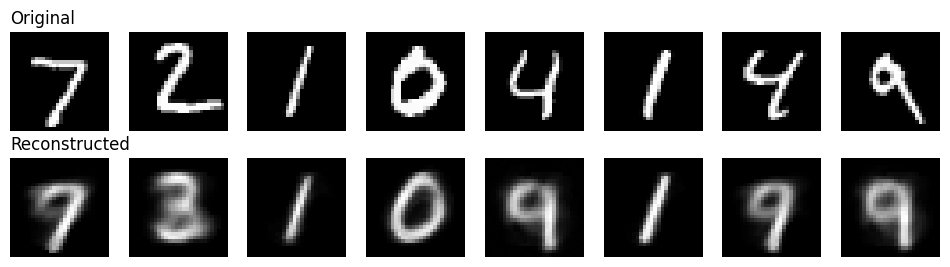

In [ ]:
ae_model.eval()  # switch to evaluation mode
with torch.no_grad():
    images, _ = next(iter(test_loader))  # grab one batch of test images
    images_flat = images.view(images.size(0), -1).to(device)  # flatten them the same way as training
    outputs, _ = ae_model(images_flat)  # get reconstructions

# plot 8 originals on top row, 8 reconstructions on bottom row
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')  # original image
    axes[0, i].axis('off')
    axes[1, i].imshow(outputs[i].cpu().view(28, 28), cmap='gray')  # reshape flat output back to 28x28 to display
    axes[1, i].axis('off')
axes[0, 0].set_title("Original", loc='left')
axes[1, 0].set_title("Reconstructed", loc='left')
plt.show()

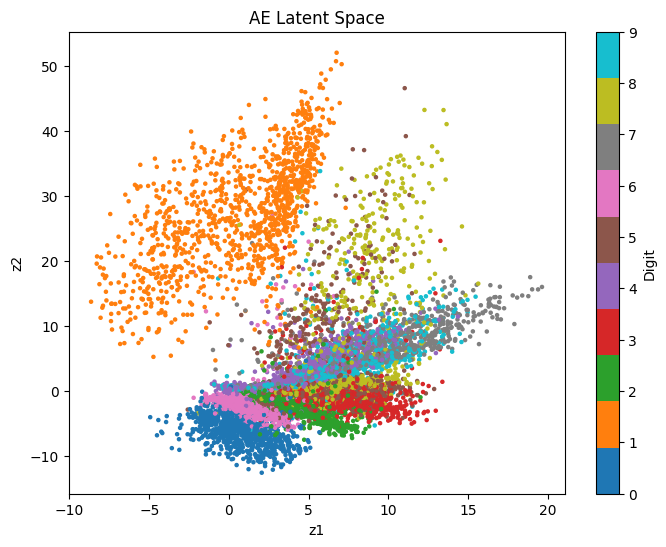

In [ ]:
#Visualize the AE's 2D latent space
ae_model.eval()
latents, labels = [], []

with torch.no_grad():
    for images, lbls in test_loader:
        images = images.view(images.size(0), -1).to(device)  # flatten
        _, z = ae_model(images)          # only need the latent vector z, ignore the reconstruction here
        latents.append(z.cpu().numpy())  # move to CPU and store as numpy array
        labels.append(lbls.numpy())      # store true digit labels (for coloring only)

latents = np.concatenate(latents)  # combine all batches into one big array
labels = np.concatenate(labels)

plt.figure(figsize=(8, 6))
# each dot = one image's (z1, z2) coordinate; color = its true digit (0-9)
scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', s=5)
plt.colorbar(scatter, label='Digit')
plt.title("AE Latent Space")
plt.xlabel("z1"); plt.ylabel("z2")
plt.show()

In [ ]:
#buliding VAE
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)          # shared first layer
        self.fc_mu = nn.Linear(128, latent_dim)     # outputs the mean of the latent distribution
        self.fc_logvar = nn.Linear(128, latent_dim) # outputs the log-variance of the latent distribution

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = torch.relu(self.fc1(x))   # shared hidden representation
        mu = self.fc_mu(h)            # branch 1: mean
        logvar = self.fc_logvar(h)    # branch 2: log-variance
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)   # convert log-variance back to standard deviation
        eps = torch.randn_like(std)     # random noise, same shape as std, drawn from standard normal
        return mu + eps * std           # the "reparameterization trick" — sample z while staying differentiable

    def forward(self, x):
        mu, logvar = self.encode(x)         # get distribution parameters
        z = self.reparameterize(mu, logvar) # sample a point from that distribution
        out = self.decoder(z)               # decode the sampled point back into an image
        return out, mu, logvar              # need mu/logvar later for the KL loss term

vae_model = VAE().to(device)
vae_optimizer = optim.Adam(vae_model.parameters(), lr=1e-3)

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    # how well did we reconstruct the image (sum over all pixels, not averaged)
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    # penalizes the latent distribution for straying from a standard normal (mean 0, var 1)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss  # total loss the model tries to minimize

In [ ]:
#training the VAE
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for images, _ in train_loader:  # again ignoring labels
        images = images.view(images.size(0), -1).to(device)
        outputs, mu, logvar = vae_model(images)     # forward pass
        loss = vae_loss(outputs, images, mu, logvar)  # combined recon + KL loss

        vae_optimizer.zero_grad()
        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()
    # divide by dataset size here (not batch count) since recon_loss used reduction='sum'
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader.dataset):.4f}")

Epoch 1/20, Loss: 206.1884
Epoch 2/20, Loss: 175.5771
Epoch 3/20, Loss: 170.0601
Epoch 4/20, Loss: 166.7465
Epoch 5/20, Loss: 164.8221
Epoch 6/20, Loss: 163.4527
Epoch 7/20, Loss: 162.3388
Epoch 8/20, Loss: 161.4100
Epoch 9/20, Loss: 160.7060
Epoch 10/20, Loss: 159.9982
Epoch 11/20, Loss: 159.4309
Epoch 12/20, Loss: 158.8604
Epoch 13/20, Loss: 158.3290
Epoch 14/20, Loss: 157.8024
Epoch 15/20, Loss: 157.3506
Epoch 16/20, Loss: 156.9086
Epoch 17/20, Loss: 156.4828
Epoch 18/20, Loss: 156.0410
Epoch 19/20, Loss: 155.6771
Epoch 20/20, Loss: 155.3372


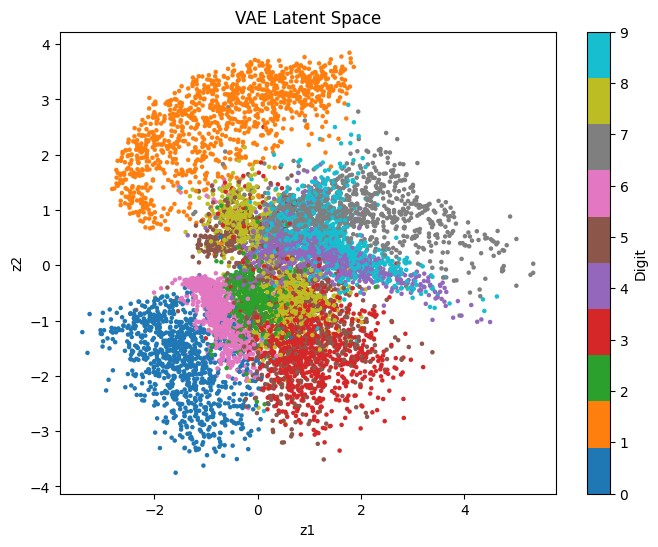

In [ ]:
#visualise the VAE latent space
vae_model.eval()
vae_latents, vae_labels = [], []
with torch.no_grad():
    for images, lbls in test_loader:
        images = images.view(images.size(0), -1).to(device)
        mu, logvar = vae_model.encode(images)  # get the distribution params, not a sampled z
        vae_latents.append(mu.cpu().numpy())   # use mu (the mean) — deterministic, not noisy
        vae_labels.append(lbls.numpy())

vae_latents = np.concatenate(vae_latents)
vae_labels = np.concatenate(vae_labels)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(vae_latents[:, 0], vae_latents[:, 1], c=vae_labels, cmap='tab10', s=5)
plt.colorbar(scatter, label='Digit')
plt.title("VAE Latent Space")
plt.xlabel("z1"); plt.ylabel("z2")
plt.show()

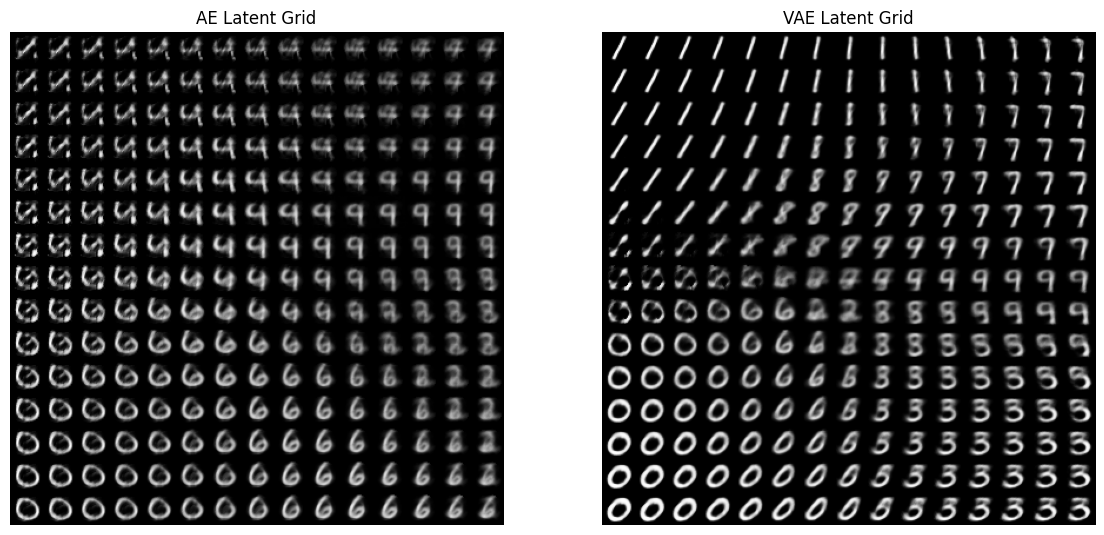

In [ ]:
#Sample random z's and compare latent grids
def plot_latent_grid(decode_fn, n=15, digit_size=28, range_=3):
    grid_x = np.linspace(-range_, range_, n)       # n evenly spaced values along z1
    grid_y = np.linspace(-range_, range_, n)[::-1]  # same for z2, reversed so image isn't upside down
    figure = np.zeros((digit_size * n, digit_size * n))  # blank canvas to hold the full mosaic

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)  # made-up coordinate
                decoded = decode_fn(z_sample).cpu().numpy().reshape(digit_size, digit_size)  # decode it into an image
                # place this decoded digit into its spot in the big mosaic
                figure[i*digit_size:(i+1)*digit_size, j*digit_size:(j+1)*digit_size] = decoded
    return figure

ae_grid = plot_latent_grid(ae_model.decoder)   # build mosaic using the AE's decoder
vae_grid = plot_latent_grid(vae_model.decoder) # build mosaic using the VAE's decoder

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(ae_grid, cmap='gray'); axes[0].set_title("AE Latent Grid"); axes[0].axis('off')
axes[1].imshow(vae_grid, cmap='gray'); axes[1].set_title("VAE Latent Grid"); axes[1].axis('off')
plt.show()

# **Summary:**

The plain Autoencoder achieved a low reconstruction loss (0.0625 → 0.0431
over 20 epochs), but its 2D latent space (z1: -10 to 20, z2: -10 to 50) was sparse and
unevenly organized — digits 0 and 1 formed distinct clusters, while digits 2-9 overlapped
heavily in one crowded region, leaving large unused gaps elsewhere. Sampling random points
from this space produced blurry, low-contrast reconstructions, since the decoder was never
trained on coordinates in those empty regions. The VAE, trained with an added KL divergence
term, produced a much more compact and centered latent space (z1: -3 to 5, z2: -4 to 4) by
construction, actively pulling all encoded points toward a standard normal distribution.
While digit clusters still overlapped in the middle (expected, since no labels were used
during training), the space as a whole was dense and continuous with no large empty regions.
Sampling random z vectors from it yielded sharp, recognizable digits that morph gradually
into one another across the latent grid, confirming that KL regularization successfully
shaped the latent space into one suitable for generating new, realistic samples — something
the plain AE's sparse, sprawling latent space could not reliably support.